In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/
!pwd

/content/drive/MyDrive
/content/drive/MyDrive


In [3]:
#필수 패키지 불러오기
import torch
import os
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import copy

In [4]:
!pwd

/content/drive/MyDrive


In [5]:
#데이터 수집, 불러오기 및 전처리
  # torchvision.transform을 통해 augmentation 진행, 데이터를 늘림
  # 단순히 데이터를 크롭하고 늘리는 것도 성능 향상에 도움이 됨

#훈련과 테스트를 위한 데이터 변형
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), #이미지를 224*224 로 랜덤하게 크롭
        transforms.RandomHorizontalFlip(), #이미지를 랜덤하게 좌우 반전
        transforms.ToTensor(), #텐서로 바꿈
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #앞에꺼 평균, 뒤에꺼 표준편차
    ]),
    'val': transforms.Compose([
        transforms.Resize(256), #이미지 짧은 변을 256으로
        transforms.CenterCrop(224),#자름
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #평균, 표준편차
    ]),
}

data_dir = './content/drive/MyDrive/Colab_Notebooks/data/transferlearning'

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True) for x in ['train', 'val']} #딕셔너리를 생성

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
device = 'cuda'

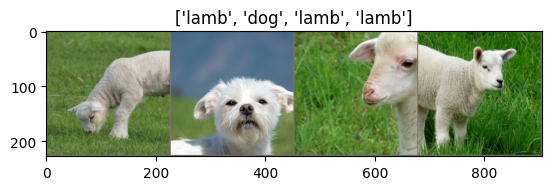

In [6]:
#랜덤으로 크롭된 훈련 데이터 확인

def imshow(inp, title=None):
  inp = inp.numpy().transpose((1,2,0)) #numpy 는 transpose, 텐서는 permute
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  inp = std * inp + mean
  inp = np.clip(inp, 0, 1)
  plt.imshow(inp)
  if title is not None:
    plt.title(title)
  plt.pause(0.001)

inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [7]:
#모델 정의 및 훈련
  # 파이토치에는 약 7종류의 미리 훈련된 모델이 존재. torchvision.models.[원하는 이름](pretrained=True)라고 쓰면 불러올 수 있음
def get_model(num_classes, freeze_conv=False):
  """ num_classes: 새로운 분류기를 만들기 위한 카테고리 개수
      freeze_conv: 참일 경우, 합성곱 신경망 층은 미리 훈련된 파라미터로 두고, FC layer의 파라미터만 변경
  """
  model = models.resnet18(pretrained=True)
  if freeze_conv:
    for param in model.parameters():
        param.requires_grad = False #freeze_conv가 참이면 역전파 과정에서 가중치 업데이트 안함
  in_feature = model.fc.in_features
  model.fc = nn.Linear(in_feature, num_classes)
  return model

model = get_model(len(class_names), freeze_conv=False).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
def train_model(model, criterion, optimizer, device, n_step=25):
    # 제일 성능이 좋았던 모델의 상태를 저장하기 위한 변수 정의
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for step in range(n_step):
        print('Step {}/{}'.format(step+1, n_step)) #몇번째 스텝인지 나타냄
        print('-' * 10)

        # 매 스텝마다 훈련과 평가를 반복한다.
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # 모델을 훈련 모드로 전환
            else:
                model.eval()   # 모델을 평가 모드로 전환

            running_loss = 0.0
            running_corrects = 0

            # 훈련 시작
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # 경사 초기화
                optimizer.zero_grad()

                # 순방향 전파
                # 빠른 계산을 위해서 훈련 모드에만 경사를 추적하게 한다
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    # 손실값 계산
                    loss = criterion(outputs, labels)

                    # 훈련 단계에서만 역전파 + 매개변수 업데이트를 진행
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # 한 번의 미니배치의 손실값 및 정확도 계산
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # 한 스텝의 손실값 및 정확도 계산
            step_loss = running_loss / dataset_sizes[phase]
            step_acc = running_corrects.double() / dataset_sizes[phase]

            print('{}\t Loss: {:.4f}\t Acc: {:.4f}'.format(
                phase, step_loss, step_acc))

            # 평가 단계에서만 정확도를 기준으로 모델 상태 저장
            if phase == 'val' and step_acc > best_acc:
                best_acc = step_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    print('Best val Acc: {:4f}'.format(best_acc))

    # 제일 학습이 좋았던 상태를 불러온다.
    model.load_state_dict(best_model_wts)
    return model

In [9]:
model = train_model(model, loss_function, optimizer, device, n_step=15)

Step 1/15
----------
train	 Loss: 1.0485	 Acc: 0.4000
val	 Loss: 0.6438	 Acc: 1.0000

Step 2/15
----------
train	 Loss: 0.6998	 Acc: 0.6545
val	 Loss: 0.3273	 Acc: 1.0000

Step 3/15
----------
train	 Loss: 0.4415	 Acc: 0.8182
val	 Loss: 0.4402	 Acc: 0.6667

Step 4/15
----------
train	 Loss: 0.4989	 Acc: 0.8364
val	 Loss: 0.2876	 Acc: 0.8333

Step 5/15
----------
train	 Loss: 0.4194	 Acc: 0.8727
val	 Loss: 0.3530	 Acc: 0.8333

Step 6/15
----------
train	 Loss: 0.2646	 Acc: 0.8909
val	 Loss: 0.4845	 Acc: 0.6667

Step 7/15
----------
train	 Loss: 0.3150	 Acc: 0.8909
val	 Loss: 0.4355	 Acc: 0.8333

Step 8/15
----------
train	 Loss: 0.4714	 Acc: 0.7818
val	 Loss: 0.1307	 Acc: 1.0000

Step 9/15
----------
train	 Loss: 0.3311	 Acc: 0.8909
val	 Loss: 0.1068	 Acc: 1.0000

Step 10/15
----------
train	 Loss: 0.3448	 Acc: 0.8909
val	 Loss: 0.0480	 Acc: 1.0000

Step 11/15
----------
train	 Loss: 0.2090	 Acc: 0.9273
val	 Loss: 0.1131	 Acc: 1.0000

Step 12/15
----------
train	 Loss: 0.2811	 Acc: 0.90

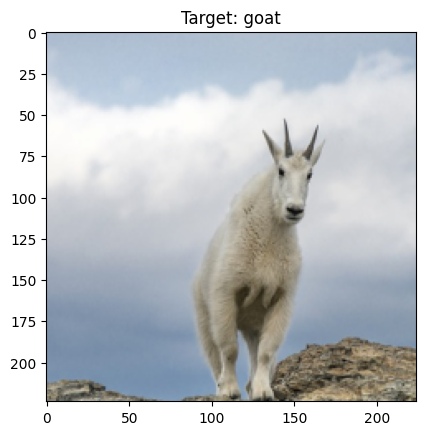

goat


In [23]:
test_tf = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), test_tf)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1)
inputs, label = next(iter(test_loader))
out = torchvision.utils.make_grid(inputs)
imshow(out, title="Target: "+class_names[label+1])

pred = model(inputs.to(device)).argmax(1)
print(class_names[pred])